# Classification and Evaluation in NLP

**Text classification** is a common Natural Language Processing (NLP) task where a model assigns a predefined category or label to a piece of text.

Examples include:
- Spam detection
- Sentiment analysis
- News categorization

In this lab, we will learn how to build and evaluate a text classification model.

## Case Study: Sentiment Analysis

Sentiment analysis, also known as opinion mining, its goal is to understand the information present in the text and categorize it as positive, negative, or neutral.

**Name:** Abdullah Hejji Alnuwaysir  
**ID:** 2240005501

# Use Case:  Amazon reviews of unlocked phone analysis

The objective of this use case is to conduct sentiment analysis on Amazon reviews of unlocked phones, categorizing reviews into three classes: positive, negative, and neutral. The goal is to gain a comprehensive understanding of customer opinions and sentiments regarding various unlocked phone models.

- Dataset link: https://www.kaggle.com/datasets/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

Task1: Load the data and do 5 different preprocessing steps on it

Task2: Use a proper train and test split

Task3: Do Feature Extraction Using TF-IDF

Task4: Train a Naive Bayes Classifier

Task5: Evaluate the model on the Test Set

Task6: Print the Confusion Matrix

### Task 1: Load the data and do 5 different preprocessing steps

In [3]:
# Import necessary libraries
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Load the dataset
amazon_data = pd.read_csv(r"C:\Users\sssab\Downloads\NLP\lab\lab4\Amazon_Unlocked_Mobile.csv", encoding='latin-1')
amazon_data.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sssab\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sssab\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\sssab\AppData\Roaming\nltk_data...


,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0


In [ ]:
# Check the shape and missing values
print("Shape:", amazon_data.shape)
amazon_data.isna().sum()

Shape: (413840, 6)


Product Name        0
Brand Name      65171
Price            5933
Rating              0
Reviews            70
Review Votes    12296
dtype: int64

In [ ]:
# Preprocessing step 0: Drop rows with missing Reviews or Rating, then create the Sentiment label
amazon_data = amazon_data.dropna(subset=['Reviews', 'Rating'])

amazon_data['Sentiment'] = amazon_data['Rating'].apply(
    lambda rating: 'positive' if rating > 3 else ('negative' if rating < 3 else 'neutral')
)

amazon_data['Sentiment'].value_counts()

Sentiment
positive    284948
negative     97059
neutral      31763
Name: count, dtype: int64

In [ ]:
# 5 preprocessing steps applied to the review text:
# 1. Convert text to lowercase
# 2. Remove punctuation and special characters (keep only letters and spaces)
# 3. Tokenize the text (split into words)
# 4. Remove stopwords (common words that carry little sentiment information)
# 5. Lemmatize each word (reduce words to their base/dictionary form)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # 1. Lowercase
    text = str(text).lower()

    # 2. Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Tokenize
    words = text.split()

    # 4. Remove stopwords
    words = [w for w in words if w not in stop_words]

    # 5. Lemmatize
    words = [lemmatizer.lemmatize(w) for w in words]

    return ' '.join(words)

# Apply preprocessing to the review text
amazon_data['Cleaned_Review'] = amazon_data['Reviews'].apply(preprocess_text)

# Display cleaned reviews
amazon_data[['Reviews', 'Cleaned_Review', 'Sentiment']].head()

,Reviews,Cleaned_Review,Sentiment
0,I feel so LUCKY to have found this used (phone...,feel lucky found used phone u used hard phone ...,positive
1,"nice phone, nice up grade from my pantach revu...",nice phone nice grade pantach revue clean set ...,positive
2,Very pleased,pleased,positive
3,It works good but it goes slow sometimes but i...,work good go slow sometimes good phone love,positive
4,Great phone to replace my lost phone. The only...,great phone replace lost phone thing volume bu...,positive


### Task 2: Use a proper train and test split

In [ ]:
from sklearn.model_selection import train_test_split

# Split the dataset into training (80%) and testing (20%) sets
# stratify=amazon_data['Sentiment'] keeps the same class proportions in both sets
train_data, test_data, train_labels, test_labels = train_test_split(
    amazon_data['Cleaned_Review'],
    amazon_data['Sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=amazon_data['Sentiment']
)

print(f"train_data size: {train_data.shape}")
print(f"test_data size: {test_data.shape}")

train_data size: (331016,)
test_data size: (82754,)


### Task 3: Do Feature Extraction Using TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF Vectorization - limit vocabulary to the 1000 most informative tokens
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)

print("Train vectors shape:", train_vectors.shape)
print("Test vectors shape:", test_vectors.shape)

Train vectors shape: (331016, 1000)
Test vectors shape: (82754, 1000)


### Task 4: Train a Naive Bayes Classifier

In [ ]:
from sklearn.naive_bayes import MultinomialNB

# Train the Multinomial Naive Bayes classifier (a common choice for text/TF-IDF features)
nb_classifier = MultinomialNB()
nb_classifier.fit(train_vectors, train_labels)

# Predictions on the test set
nb_predictions = nb_classifier.predict(test_vectors)
nb_predictions[:10]

array(['positive', 'positive', 'negative', 'positive', 'positive',
       'positive', 'positive', 'positive', 'positive', 'positive'],
      dtype='<U8')

### Task 5: Evaluate the model on the Test Set

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Evaluate the model
accuracy = accuracy_score(test_labels, nb_predictions)
print(f"Accuracy: {accuracy:.2f}")

# Display classification report
print("Classification Report:")
print(classification_report(test_labels, nb_predictions))

Accuracy: 0.82
Classification Report:


              precision    recall  f1-score   support

    negative       0.79      0.66      0.72     19412
     neutral       0.32      0.02      0.04      6352
    positive       0.84      0.97      0.90     56990

    accuracy                           0.82     82754
   macro avg       0.65      0.55      0.55     82754
weighted avg       0.79      0.82      0.79     82754



### Task 6: Print the Confusion Matrix

Confusion Matrix:
[[12884    77  6451]
 [ 1788   130  4434]
 [ 1623   197 55170]]


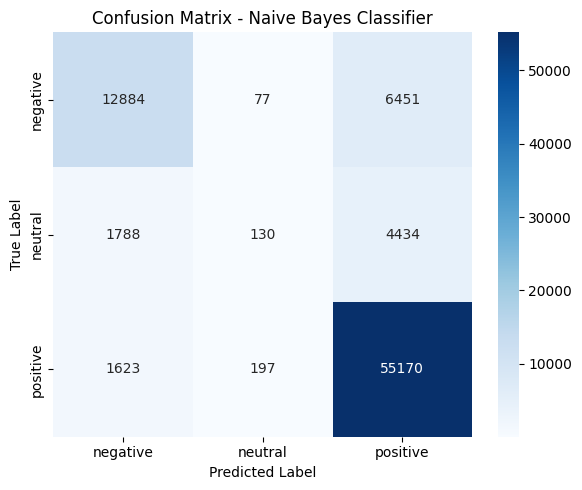

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

labels_order = nb_classifier.classes_
cm = confusion_matrix(test_labels, nb_predictions, labels=labels_order)

print("Confusion Matrix:")
print(cm)

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_order, yticklabels=labels_order)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Naive Bayes Classifier')
plt.tight_layout()
plt.show()